In [1]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
import torch
from torch.utils.data import random_split, DataLoader
from model.neumf import NeuMF
from utils.dataset import Observe
import matplotlib.pyplot as plt


In [9]:
embedding_size = 64
batch_size = 1024
data = "coat"

In [10]:
train = Observe(data, True, 1)
user_num = train.user_num
item_num = train.item_num

train_size  = int(0.9 * len(train))
validation_size = len(train) - train_size
train, validation = random_split(train, [train_size, validation_size])

train_loader = DataLoader(dataset=train, batch_size=1024, shuffle=True, num_workers=8)
val_loader = DataLoader(dataset=validation, batch_size=1024, shuffle=True, num_workers=8)


In [11]:
lr = 1e-3
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = NeuMF(user_num, item_num,  embedding_size, embedding_size, [32, 16, 8])
checkpoint = torch.load(f'saved_propensity_model/neumf_propensity_{data}.ckpt')
model.load_state_dict(checkpoint['net'])

<All keys matched successfully>

In [12]:
predictions= torch.empty(0)
y_true = torch.empty(0)

for user, item, label in val_loader:
    pred = model(user, item)
    predictions = torch.cat((predictions, pred))
    y_true = torch.cat((y_true, label))

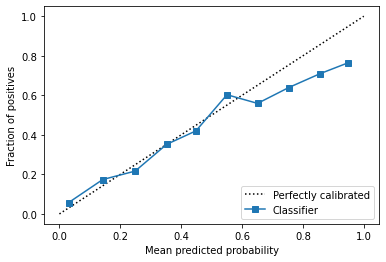

In [13]:
disp = CalibrationDisplay.from_predictions(y_true.detach().numpy(), predictions.detach().numpy(), n_bins=10)

plt.show()